In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Path to your image
IMAGE_PATH = "test3.png"  # change this if needed

# Load image using OpenCV (BGR format)
image = cv2.imread(IMAGE_PATH)

# Sanity check
if image is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

print("Image loaded successfully")
print("Image shape (H, W, C):", image.shape)


Image loaded successfully
Image shape (H, W, C): (1080, 1920, 3)


In [3]:
ROI_POINTS = [
    (1000, 50),   # top-left
    (1300, 0),    # top-right
    (1300, 300),  # bottom-right
    (1000, 300),  # bottom-left
]

# Simple HSV ranges (tune later if needed)
HSV_RANGES = {
    "green": (np.array([35,  40,  40]), np.array([85,  255, 255])),
    "blue":  (np.array([90,  40,  40]), np.array([130, 255, 255])),
    # red wraps around hue=0, so we use two ranges
    "red1":  (np.array([0,   40,  40]), np.array([10,  255, 255])),
    "red2":  (np.array([160, 40,  40]), np.array([180, 255, 255])),
}

# Decision threshold: fraction of ROI pixels that must match a color
MIN_FRACTION = 0.05  # 5% (start low for markers/dots)


In [4]:
def quad_mask(shape_hw, points):
    """Create a uint8 mask (255 inside quad, 0 outside)."""
    h, w = shape_hw
    mask = np.zeros((h, w), dtype=np.uint8)
    pts = np.array(points, dtype=np.int32)
    cv2.fillPoly(mask, [pts], 255)
    return mask


In [5]:
def color_fractions_in_roi(bgr_image, roi_points):
    hsv = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2HSV)

    h_img, w_img = bgr_image.shape[:2]
    mask_roi = quad_mask((h_img, w_img), roi_points)

    # Count only ROI pixels
    roi_pixel_count = int(np.count_nonzero(mask_roi))
    if roi_pixel_count == 0:
        return {"green": 0.0, "blue": 0.0, "red": 0.0}

    # Green
    green_mask = cv2.inRange(hsv, *HSV_RANGES["green"])
    green_mask = cv2.bitwise_and(green_mask, green_mask, mask=mask_roi)
    green_frac = np.count_nonzero(green_mask) / roi_pixel_count

    # Blue
    blue_mask = cv2.inRange(hsv, *HSV_RANGES["blue"])
    blue_mask = cv2.bitwise_and(blue_mask, blue_mask, mask=mask_roi)
    blue_frac = np.count_nonzero(blue_mask) / roi_pixel_count

    # Red (two ranges)
    red_mask1 = cv2.inRange(hsv, *HSV_RANGES["red1"])
    red_mask2 = cv2.inRange(hsv, *HSV_RANGES["red2"])
    red_mask = cv2.bitwise_or(red_mask1, red_mask2)
    red_mask = cv2.bitwise_and(red_mask, red_mask, mask=mask_roi)
    red_frac = np.count_nonzero(red_mask) / roi_pixel_count

    return {"green": float(green_frac), "blue": float(blue_frac), "red": float(red_frac)}


In [6]:
def decide_color(fractions, min_fraction=0.05):
    # Pick the highest fraction
    color = max(fractions, key=fractions.get)
    score = fractions[color]

    if score < min_fraction:
        return "none", score

    return color, score


In [7]:
def execute_action():
    print("[ACTION] GREEN detected → executing main function")


def debug_red():
    print("[DEBUG] RED detected → executing red debug function")


def debug_blue():
    print("[DEBUG] BLUE detected → executing blue debug function")


In [8]:
def draw_roi_overlay(bgr_image, roi_points, label):
    overlay = bgr_image.copy()
    pts = np.array(roi_points, dtype=np.int32)

    cv2.polylines(overlay, [pts], isClosed=True, color=(0, 255, 255), thickness=3)
    x0, y0 = roi_points[0]
    cv2.putText(
        overlay, label, (x0, max(0, y0 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2
    )
    return overlay


=== ROI COLOR CHECK ===
Fractions: {'green': 0.0678, 'blue': 0.0, 'red': 0.0}
Decision: green score= 0.0678
[ACTION] GREEN detected → executing main function


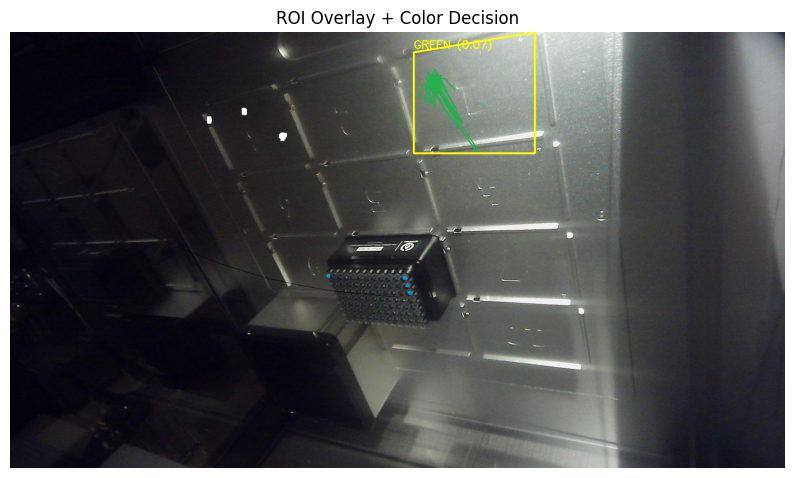

In [9]:
fractions = color_fractions_in_roi(image, ROI_POINTS)
color, score = decide_color(fractions)

print("=== ROI COLOR CHECK ===")
print("Fractions:", {k: round(v, 4) for k, v in fractions.items()})
print("Decision:", color, "score=", round(score, 4))

# Branch
if color == "green":
    execute_action()
elif color == "red":
    debug_red()
elif color == "blue":
    debug_blue()
else:
    print("[INFO] No target color detected in ROI (below threshold)")

# Visual overlay in notebook
label = f"{color.upper()} ({score:.2f})"
overlay = draw_roi_overlay(image, ROI_POINTS, label)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("ROI Overlay + Color Decision")
plt.axis("off")
plt.show()


In [10]:
import json
from datetime import datetime

result = {
    "color": color,
    "score": float(score),
    "fractions": {k: float(v) for k, v in fractions.items()},
    "timestamp": datetime.utcnow().isoformat(),
}

with open("vision_result.json", "w") as f:
    json.dump(result, f, indent=2)

print("[VISION] Wrote vision_result.json:", result)


[VISION] Wrote vision_result.json: {'color': 'green', 'score': 0.0677776306125152, 'fractions': {'green': 0.0677776306125152, 'blue': 2.4081588421572286e-05, 'red': 0.0}, 'timestamp': '2026-04-07T16:54:14.400583'}
